# DataLab Task 2: Petri Dish Detection and Extraction

## Instructions

In computer vision, **Region of Interest (ROI) extraction** is a technique used to identify and isolate specific parts of an image that are deemed important for further analysis. By focusing only on the relevant areas, ROI extraction enhances both the efficiency and accuracy of subsequent image processing tasks.

In this project, the **ROI is the Petri Dish**. The goal of Task 2 is to implement a Python solution using traditional computer vision methods to automatically crop the Petri dish from raw images provided in the datasets **Y2B_23** and **Y2B_24**.

**Key details:**
- The Petri dish is a square with edges parallel to image borders, though its position varies.
- **Y2B_23** images include a white legend on the right, while **Y2B_24** images do not.
- The output will be a square image containing only the Petri dish.

Lets start by importing necessary modules and libraries.

In [1]:
import cv2
import skimage
import matplotlib.pyplot as plt
import numpy as np

### Loading and Converting the Image to Grayscale

The first step in the image processing pipeline is to load the raw image and convert it to grayscale. This is necessary because many image processing operations (such as edge detection, thresholding, and contour detection) work more effectively with single-channel grayscale images rather than multi-channel color images.

The height of the image is 3006 and the width is 4202.


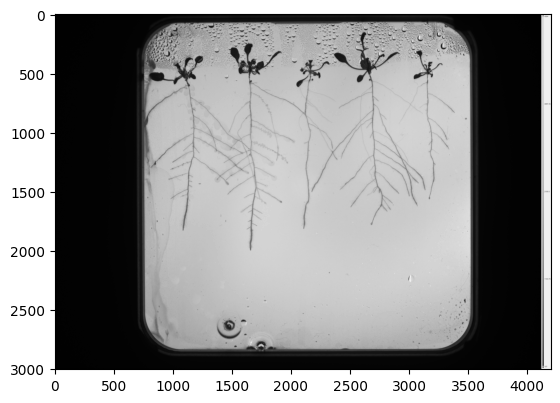

In [2]:
# Load the image in grayscale mode
image = cv2.imread('images/Y2B_23_im1.png', 0)

# Retrieve the image dimensions
height, width = image.shape

# Display the image dimensions
print(f"The height of the image is {height} and the width is {width}.")

# Visualize the grayscale image
plt.imshow(image, cmap='gray')

### Checking the Right-Side Columns for a Bright Legend

In this step, we analyze the right side of the image to determine if a bright legend is present. Images from the Y2B_23 dataset contain a bright legend on the right edge, while images from the Y2B_24 dataset usually do not. Detecting the presence of this legend is crucial for standardizing the dataset by cropping it out when necessary.

In [3]:
# Extract the last 20 columns of the image
right_columns = image[:, -20:]

# Calculate the mean intensity of the right-most columns
mean_intensity = np.mean(right_columns)
print(f"Mean intensity of right columns: {mean_intensity}")

Mean intensity of right columns: 239.7982368596141


### Thresholding to Decide if a Legend Exists and Cropping

After calculating the mean intensity of the rightmost columns in the previous step, we use a threshold to determine if a bright legend is present. If the mean intensity is high, the pixels on the right side of the image are of a very bright color, indicating that a legend has been detected. If the legend exists (indicating an image from the Y2B_23 dataset), it is cropped out to standardize the dataset. For images from the Y2B_24 dataset, no cropping is needed.

Legend detected: Cropping right side (Y2B_23)


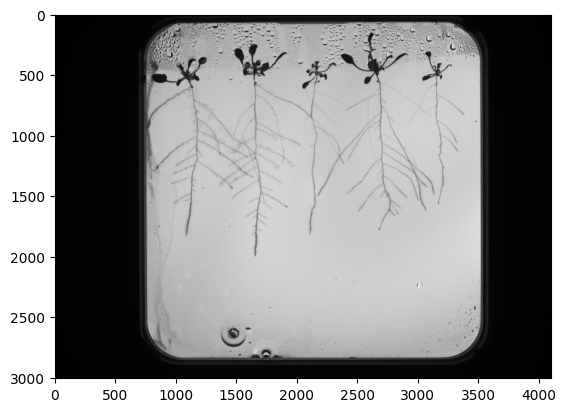

In [4]:
# Threshold to decide if a legend exists
threshold = 200 
if mean_intensity > threshold:
    print("Legend detected: Cropping right side (Y2B_23)")
    # Crop out the legend
    image_cropped = image[:, :-100]  # Remove ~100 pixels from the right
else:
    print("No legend detected (Y2B_24)")
    image_cropped = image

# Show the cropped image
plt.imshow(image_cropped, cmap = 'gray')

### Applying Gaussian Blur to Reduce Noise

In this step, we apply a Gaussian blur to the cropped image to reduce noise and smooth out variations in pixel intensity. This helps improve the results of subsequent image processing operations such as thresholding and contour detection.

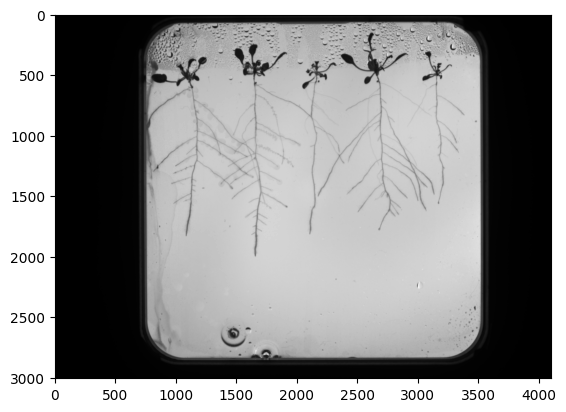

In [5]:
# Apply Gaussian blur to reduce noise
blurred_image = cv2.GaussianBlur(image_cropped, (11, 11), 0)

# Display the blurred image
plt.imshow(blurred_image, cmap='gray')

### Applying Otsu Thresholding

Having reduced the noise in the image, we apply Otsu’s thresholding method to convert the blurred grayscale image into a binary image. This operation separates the foreground (e.g., the Petri dish) from the background based on intensity values, producing a binary output where each pixel is either black or white.

Threshold value: 100.0


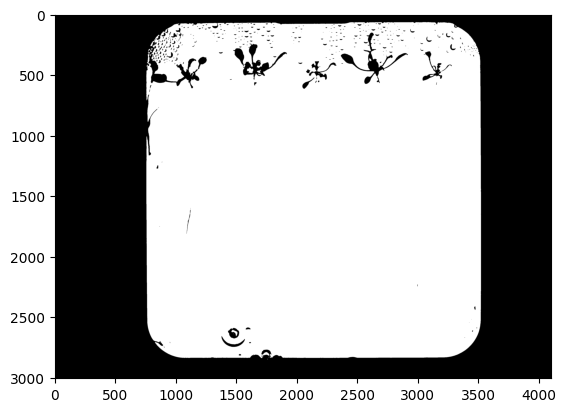

In [6]:
# Apply Otsu Thresholding
threshold_value, otsu_thresh = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Threshold value:", threshold_value)

# Display the binary image after thresholding
plt.imshow(otsu_thresh, cmap='gray')

### Finding Contours

The next step is to use the binary image produced by Otsu thresholding to detect contours. Contours are continuous curves that connect all points along the boundary of a shape with the same intensity, making them ideal for identifying the edges of the Petri dish.

In [7]:
# Find the contours
thresholded_image = otsu_thresh
contours, hierarchy = cv2.findContours(thresholded_image, 
    mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE)

After detecting contours in the binary image, we can visualize the detected contours by drawing them directly on the image. This visualization helps verify that the contours correctly identify the boundaries of the Petri dish.

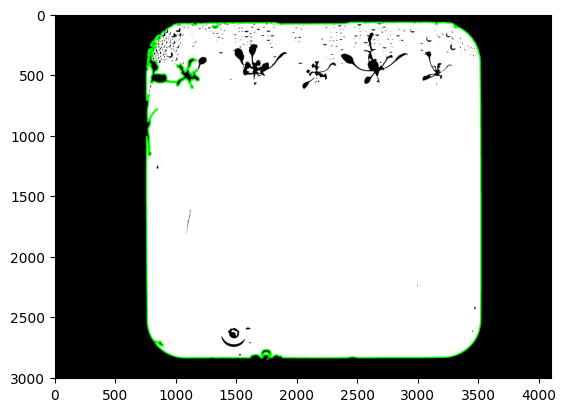

In [8]:
# Convert the binary image to BGR for drawing colored contours
image_with_contours = cv2.cvtColor(thresholded_image, cv2.COLOR_GRAY2BGR)

# Draw all detected contours on the image
cv2.drawContours(image_with_contours, contours, contourIdx=-1, color=(0, 255, 0), thickness=10)

# Display the image with contours
plt.imshow(image_with_contours)

### Identifying the Largest Contour and Getting the Bounding Box

Next, we identify the largest contour from the list of detected contours. The largest contour is assumed to correspond to the Petri dish. We then calculate the bounding box around this contour, which will be used for cropping the Petri dish.

In [9]:
# Identify the largest contour (assumed to be the Petri dish)
largest_contour = max(contours, key=cv2.contourArea)

# Get bounding box around the largest contour
x, y, w, h = cv2.boundingRect(largest_contour)

After obtaining the bounding box, the next step is to crop the image based on this box. However, we must first adjust the bounding box dimensions to ensure the region of interest (the Petri dish) is a square. This step is crucial because the final cropped image must be square to meet the requirements of the task.

In [10]:
# Ensure the bounding box is square
size = max(w, h)  # Use the largest dimension
x_center = x + w // 2
y_center = y + h // 2
x_start = max(0, x_center - size // 2)
y_start = max(0, y_center - size // 2)

### Cropping the Square Region Containing the Petri Dish

In this final step, we crop the square region of interest (ROI) containing the Petri dish using the coordinates calculated in the previous steps. The resulting image isolates the Petri dish for further analysis or saving.

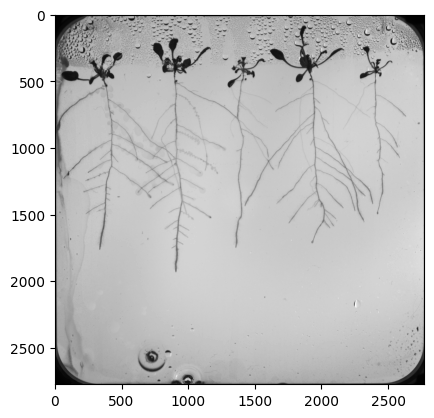

In [11]:
# Crop the square region containing the Petri dish
cropped_dish = image_cropped[y_start:y_start+size, x_start:x_start+size]

# Display the cropped Petri dish
plt.imshow(cropped_dish, cmap='gray')

### EXTRA STEP: Validating the Cropped Image

In this step, we validate that:
- The final cropped image is a square.
- The detected Petri dish edges are within the acceptable margin of error (±30 pixels) from the actual edges.

In [12]:
# Validate if the cropped image is a square
final_height, final_width = cropped_dish.shape
if final_height == final_width:
    print(f"Validation Passed: The cropped image is square with dimensions: {final_height}x{final_width}")
else:
    print(f"Validation Failed: The cropped image is NOT square with dimensions: {final_height}x{final_width}")

# Check if the edges meet the ±30 pixels requirement
x_error = abs((x + w) - (x_start + size))
y_error = abs((y + h) - (y_start + size))

if x_error <= 30 and y_error <= 30:
    print(f"Validation Passed: Detected edges are within ±30 pixels (x_error={x_error}, y_error={y_error})")
else:
    print(f"Validation Failed: Detected edges exceed ±30 pixels (x_error={x_error}, y_error={y_error})")


Validation Passed: The cropped image is square with dimensions: 2774x2774
Validation Passed: Detected edges are within ±30 pixels (x_error=5, y_error=0)


### Putting Everything Together

The code consolidates all the previously described operations into a single Python function. This function processes multiple images in a batch, detects and crops the Petri dish from each image, and saves the cropped result in a specified output folder. Here’s a step-by-step breakdown of the entire workflow:

Processing: Y2B_23_im1.png
The height of the image is 3006 and the width is 4202.
Mean intensity of right columns: 239.7982368596141
Legend detected: Cropping right side (Y2B_23)
Threshold value: 100.0
Number of contours detected: 10
Final cropped image is square: 2774x2774


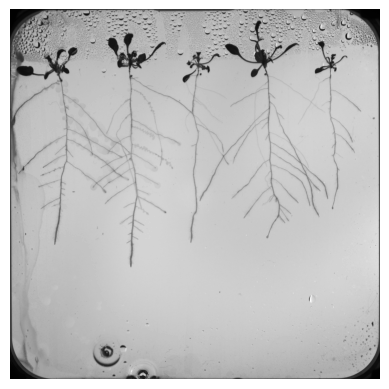

Cropped image saved to: cropped_images\cropped_Y2B_23_im1.png

Processing: Y2B_23_im2.png
The height of the image is 3006 and the width is 4202.
Mean intensity of right columns: 239.7982368596141
Legend detected: Cropping right side (Y2B_23)
Threshold value: 99.0
Number of contours detected: 5
Final cropped image is square: 2774x2774


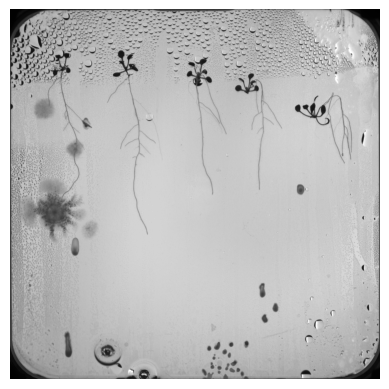

Cropped image saved to: cropped_images\cropped_Y2B_23_im2.png

Processing: Y2B_24_im1.png
The height of the image is 3006 and the width is 4202.
Mean intensity of right columns: 240.0
Legend detected: Cropping right side (Y2B_23)
Threshold value: 88.0
Number of contours detected: 6
Final cropped image is square: 2718x2718


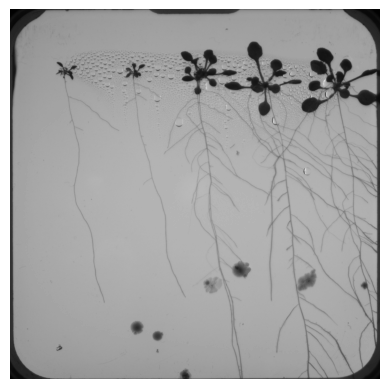

Cropped image saved to: cropped_images\cropped_Y2B_24_im1.png

Processing: Y2B_24_im2.png
The height of the image is 3006 and the width is 4112.
Mean intensity of right columns: 2.419827012641384
No legend detected (Y2B_24)
Threshold value: 90.0
Number of contours detected: 3
Final cropped image is square: 2742x2742


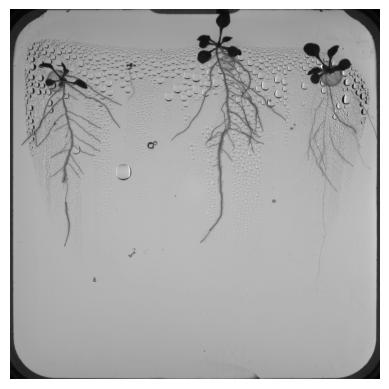

Cropped image saved to: cropped_images\cropped_Y2B_24_im2.png

Processing complete!


In [14]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

def process_and_crop_images(input_folder, output_folder):
    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)
    
    # Loop through each image in the input folder
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            image_path = os.path.join(input_folder, filename)
            print(f"Processing: {filename}")
            
            # Load and convert to grayscale
            image = cv2.imread(image_path, 0)
            height, width = image.shape
            print(f"The height of the image is {height} and the width is {width}.")
            
            # Check the right-side columns for a bright legend
            right_columns = image[:, -20:]
            mean_intensity = np.mean(right_columns)
            print(f"Mean intensity of right columns: {mean_intensity}")
            
            # Threshold to decide if a legend exists
            threshold = 200 
            if mean_intensity > threshold:
                print("Legend detected: Cropping right side (Y2B_23)")
                image_cropped = image[:, :-100]  # Remove ~100 pixels from the right
            else:
                print("No legend detected (Y2B_24)")
                image_cropped = image
            
            # Apply Gaussian blur to reduce noise
            blurred_image = cv2.GaussianBlur(image_cropped, (11, 11), 0)
            
            # Otsu Thresholding
            threshold_value, otsu_thresh = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            print(f"Threshold value: {threshold_value}")
            
            # Find contours
            contours, hierarchy = cv2.findContours(otsu_thresh, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE)
            print(f"Number of contours detected: {len(contours)}")
            
            # Identify the largest contour
            largest_contour = max(contours, key=cv2.contourArea)
            
            # Get bounding box around the largest contour and ensure square
            x, y, w, h = cv2.boundingRect(largest_contour)
            size = max(w, h)
            x_center = x + w // 2
            y_center = y + h // 2
            x_start = max(0, x_center - size // 2)
            y_start = max(0, y_center - size // 2)
            
            # Crop the Petri dish
            cropped_dish = image_cropped[y_start:y_start+size, x_start:x_start+size]
            
            # Check if the cropped image is square
            final_height, final_width = cropped_dish.shape
            if final_height == final_width:
                print(f"Final cropped image is square: {final_height}x{final_width}")
            else:
                print(f"WARNING: Final cropped image is NOT square: {final_height}x{final_width}")

            # Display the cropped Petri dish without axes or decorations
            plt.imshow(cropped_dish, cmap='gray')
            plt.axis('off')  # Turn off the axis
            plt.show()
            
            # Save the cropped image to the output folder
            output_path = os.path.join(output_folder, f"cropped_{filename}")
            cv2.imwrite(output_path, cropped_dish)
            print(f"Cropped image saved to: {output_path}\n")
    
    print("Processing complete!")

# Call the function
input_folder = 'images'  # Path to the folder containing input images
output_folder = 'cropped_images'  # Path to save the cropped images
process_and_crop_images(input_folder, output_folder)
